#Motion Deblurring

The project involves deblurring images. The blurred version is obtained through a superposition of slightly translated versions of the same image, following a random trajectory. This kind of blur is supposed to simulate the result of a shot taken with a shaky hand.

In [1]:
from tensorflow.keras import layers
from keras import models, layers
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.layers import *
from keras.models import *
import numpy as np
from matplotlib import pyplot as plt

We work with images obtained from MNIST.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = (x_train/255.).astype(np.float32)
x_test = (x_test/255.).astype(np.float32)


11490434/11490434 [==============================] - 0s 0us/step


Below you can find the generator you need to use for your project. Do not modify the number of moves, nor the range of translations. You are free to change the batchsize.

In [3]:
def generator(dataset,batch_size=32,moves=10):
  while True:
    rand = np.random.randint(dataset.shape[0],size=batch_size)
    y_truth = dataset[rand]
    blurred = np.copy(y_truth)
    moving = tf.expand_dims(y_truth,axis=-1)

    for i in range(moves):
      #RandomTranslation requires a channel axis
      moving = layers.RandomTranslation(0.07,0.07,fill_mode='constant',interpolation='bilinear')(moving)
      blurred = blurred + tf.squeeze(moving)
    blurred = blurred/(moves+1)
    yield(blurred,y_truth)


In [4]:
my_gen_train = generator(x_train,60000)
my_gen_test = generator(x_test,10000)


In [5]:
def plot(x,y):
  no = x.shape[0]
  print(no)
  plt.figure(figsize=(2*no, 4))
  for i in range(no):
    # display original
    ax = plt.subplot(2, no, i + 1)
    plt.imshow(x[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, no, i + 1 + no)
    plt.imshow(y[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()

Here we plot some examples. In the first row you see the blurred image, and in the second the original image, that is the ground truth that you are suppose to obtain through deblurring.

In [6]:
my_gen_train = generator(x_train,60000)
my_gen_test = generator(x_test,10000)



train_blurred,train_original = next(my_gen_train)
test_blurred,test_original = next(my_gen_test)
# plot(train_blurred,train_original)
# from sklearn.model_selection import train_test_split
# x_train, x_val, y_train, y_val = train_test_split(train_original, train_blurred, test_size=10000, random_state=42)

train_blurred = np.expand_dims(train_blurred, axis=-1)
train_original = np.expand_dims(train_original, axis=-1)
test_blurred = np.expand_dims(test_blurred, axis=-1)
test_original = np.expand_dims(test_original, axis=-1)
x_train = np.expand_dims(x_train, axis=-1)
y_train = np.expand_dims(y_train, axis=-1)


x_val = train_original[-10000:]
y_val = train_blurred[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]
y_val.shape

(10000, 28, 28, 1)

##Training
I use an autoencoder as the architecture

In [7]:
model = models.Sequential()

# #encode


model.add(layers.Conv2D(128, (9, 9), strides = 1, padding = 'same', input_shape = (28, 28, 1),activation='relu'))
model .add(layers.AveragePooling2D(2,strides=1,padding='same'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (7, 7), strides = 1, padding = 'same',activation='relu'))
model .add(layers.AveragePooling2D(2,strides=1,padding='same'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(32, (7, 7), strides = 1, padding = 'same',activation='relu'))
model .add(layers.AveragePooling2D(2,strides=1,padding='same'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(16, (5, 5), strides = 1, padding = 'same',activation='relu'))
model .add(layers.AveragePooling2D(2,strides=1,padding='same'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(16, (5, 5), strides = 1, padding = 'same',activation='relu'))
model .add(layers.AveragePooling2D(2,strides=1,padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

#latent
model.add(layers.Conv2D(8, (2, 2), strides = 1, padding = 'same'))

#decode
model.add(layers.Conv2DTranspose(16, (9, 9), strides = 1, padding = 'same',activation='relu'))
model.add(layers.Conv2DTranspose(16, (9, 9), strides = 1, padding = 'same',activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2DTranspose(32, (7, 7), strides = 1, padding = 'same',activation='relu'))
model.add(layers.Conv2DTranspose(32, (1, 1), strides = 1, padding = 'same',activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2DTranspose(64, (5, 5), strides = 1, padding = 'same',activation='relu'))
model.add(layers.Conv2DTranspose(64, (5, 5), strides = 1, padding = 'same',activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2DTranspose(1, (1, 1), strides = 1, activation = 'sigmoid', padding = 'same'))

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 128)       10496     
                                                                 
 average_pooling2d (Average  (None, 28, 28, 128)       0         
 Pooling2D)                                                      
                                                                 
 batch_normalization (Batch  (None, 28, 28, 128)       512       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        401472    
                                                                 
 average_pooling2d_1 (Avera  (None, 28, 28, 64)        0         
 gePooling2D)                                                    
                                                        

fit the model with 10 epochs and batch_size=64

In [8]:
from keras import optimizers
# opt = optimizers.SGD(lr=5e-4)
# 'accuracy','recall','precision','
model.compile( loss="logcosh", optimizer = 'adam', metrics=['mse','accuracy'])

In [9]:
import tensorflow as tf
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
with tf.device('/device:GPU:0'):
    # tf.experimental.numpy.experimental_enable_numpy_behavior()
    model.history=model.fit( train_blurred,train_original, epochs = 10,
              validation_data = ( y_val,x_val), batch_size=64,shuffle= True,callbacks=[early_stopping])

Epoch 1/10
938/938 [==============================] - 81s 61ms/step - loss: 0.0154 - mse: 0.0326 - accuracy: 0.8026 - val_loss: 0.0097 - val_mse: 0.0204 - val_accuracy: 0.8089
Epoch 2/10
938/938 [==============================] - 57s 61ms/step - loss: 0.0084 - mse: 0.0175 - accuracy: 0.8102 - val_loss: 0.0085 - val_mse: 0.0179 - val_accuracy: 0.8087
Epoch 3/10
938/938 [==============================] - 57s 60ms/step - loss: 0.0069 - mse: 0.0144 - accuracy: 0.8114 - val_loss: 0.0064 - val_mse: 0.0134 - val_accuracy: 0.8110
Epoch 4/10
938/938 [==============================] - 58s 62ms/step - loss: 0.0059 - mse: 0.0123 - accuracy: 0.8121 - val_loss: 0.0053 - val_mse: 0.0109 - val_accuracy: 0.8133
Epoch 5/10
938/938 [==============================] - 58s 62ms/step - loss: 0.0052 - mse: 0.0108 - accuracy: 0.8126 - val_loss: 0.0050 - val_mse: 0.0104 - val_accuracy: 0.8123
Epoch 6/10
938/938 [==============================] - 58s 62ms/step - loss: 0.0047 - mse: 0.0097 - accuracy: 0.8130 - va

# Evaluation

Use Mean Squared Error (mse) to evaluate the error between the deblurred image and the ground truth.
Measure mse on 10000 blurred versions of the validation set.

Repeat the prevevious computation 10 times, and gives as a result the **mean
mse over the ten rounds, along with the standard deviation**.

In [10]:
preds = model.predict(test_blurred.reshape(-1, 28, 28,1))
result=model.evaluate(test_blurred.reshape(-1, 28, 28,1),test_original)
print( result)



313/313 [==============================] - 3s 9ms/step - loss: 0.0032 - mse: 0.0065 - accuracy: 0.8126
[0.00316264433786273, 0.006539568770676851, 0.8126102089881897]


15


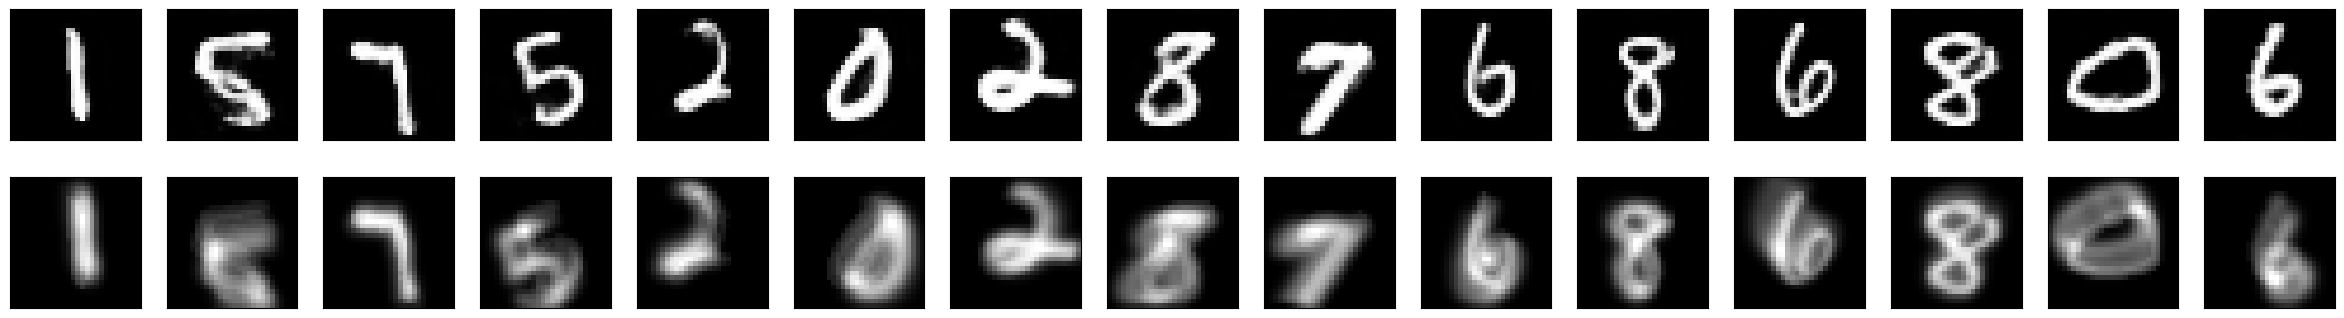

15


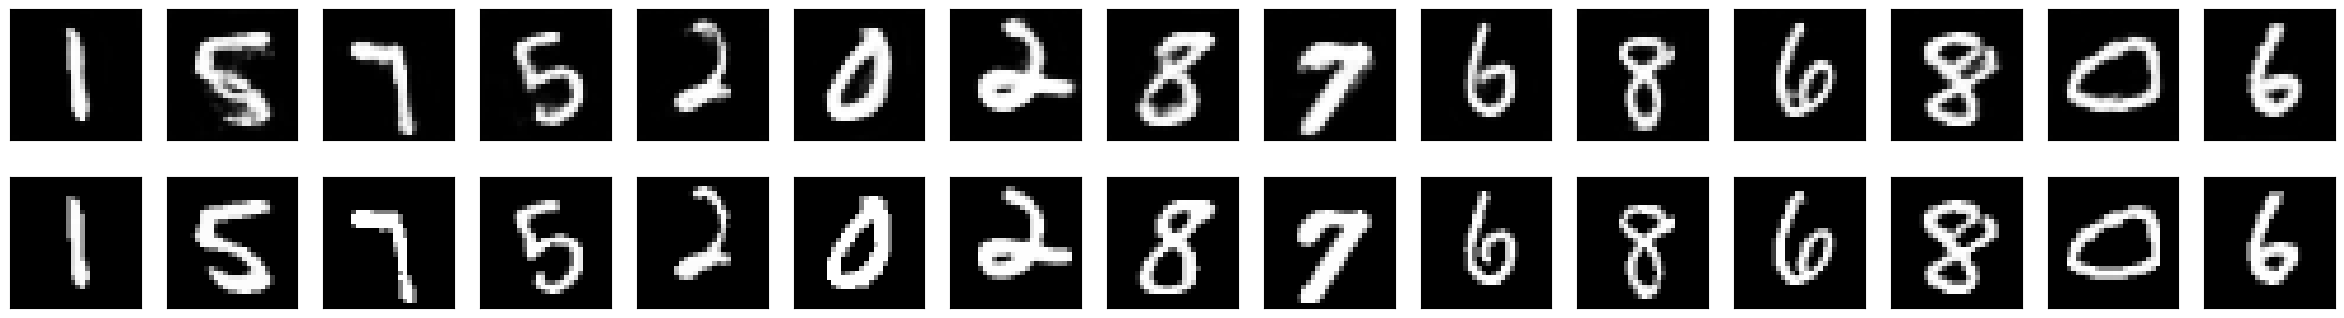

In [11]:
preds.shape
plot(preds[:15],test_blurred[:15])
plot(preds[:15],test_original[:15])

In [13]:
num_rounds = 10
mse_scores = []
tf.experimental.numpy.experimental_enable_numpy_behavior()
for i in range(num_rounds):
  test_blurred,test_original = next(my_gen_test)
  result=model.evaluate(test_blurred.reshape(-1, 28, 28,1),test_original)
  mse_scores.append(result[1])

# Calculate mean and standard deviation of MSE scores
mean_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Mean MSE :  {mean_mse}")
print(f"Standard Deviation: {std_dev_mse}")

313/313 [==============================] - 3s 10ms/step - loss: 0.0031 - mse: 0.0065 - accuracy: 0.8126
Mean MSE :  0.006454520439729094
Standard Deviation: 6.398365525752684e-05
